# **1. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

# **2. Memuat Dataset Hasil Clustering**

In [2]:
df = pd.read_csv("Dataset_inisiasi.csv")
df.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,TransactionDuration,CustomerOccupation,AccountBalance,Cluster
0,14.09,Debit,ATM,70,81,Doctor,5112.21,0
1,376.24,Debit,ATM,68,141,Doctor,13758.91,2
2,126.29,Debit,Online,19,56,Student,1122.35,1
3,184.50,Debit,Online,26,25,Student,8569.06,0
4,13.45,Credit,Online,26,198,Student,7429.40,0


# **3. Data Splitting**

Encoding Data Kategorikal

In [3]:
# List kolom kategori yang perlu di-encode
categorical_columns = ["TransactionType", "Channel", "CustomerOccupation"]

In [4]:
# Inisiasi LabelEncoder
label_encoder = LabelEncoder()

# Encode kolom kategori
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

df.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,TransactionDuration,CustomerOccupation,AccountBalance,Cluster
0,14.09,1,0,70,81,0,5112.21,0
1,376.24,1,0,68,141,0,13758.91,2
2,126.29,1,2,19,56,3,1122.35,1
3,184.50,1,2,26,25,3,8569.06,0
4,13.45,0,2,26,198,3,7429.40,0


Normalisasi Data Numerik

In [5]:
# List kolom kategori yang perlu dinormalisasi
numerical_columns = ["TransactionAmount", "CustomerAge", "TransactionDuration", "AccountBalance"]

In [6]:
# Inisiasi Scaler
scaler = MinMaxScaler()

# Normalisasi kolom numerik
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

df.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,TransactionDuration,CustomerOccupation,AccountBalance,Cluster
0,0.015317,1,0,0.838710,0.244828,0,0.336832,0
1,0.416400,1,0,0.806452,0.451724,0,0.918055,2
2,0.139579,1,2,0.016129,0.158621,3,0.068637,1
3,0.204047,1,2,0.129032,0.051724,3,0.569198,0
4,0.014608,0,2,0.129032,0.648276,3,0.492591,0


Data Split

In [7]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=["Cluster"])
y = df["Cluster"]

# Split dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Ukuran data train: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Ukuran data test: X_test={X_test.shape}, y_test={y_test.shape}")

Ukuran data train: X_train=(1825, 7), y_train=(1825,)
Ukuran data test: X_test=(457, 7), y_test=(457,)


# **4. Membangun Model Klasifikasi**

## **a. Model Klasifikasi**

In [8]:
# Inisialisasi model
rf_model = RandomForestClassifier()
lr_model = LogisticRegression()

# Latih model dengan data latih
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

LogisticRegression()

## **b. Evaluasi Model Klasifikasi**

In [9]:
# Prediksi di data uji
y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

# Evaluasi model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print(f"Random Forest - Accuracy: {accuracy_rf:.4f}, F1-Score: {f1_rf:.4f}")
print(f"Logistic Regression - Accuracy: {accuracy_lr:.4f}, F1-Score: {f1_lr:.4f}")

Random Forest - Accuracy: 1.0000, F1-Score: 1.0000
Logistic Regression - Accuracy: 0.9628, F1-Score: 0.9623


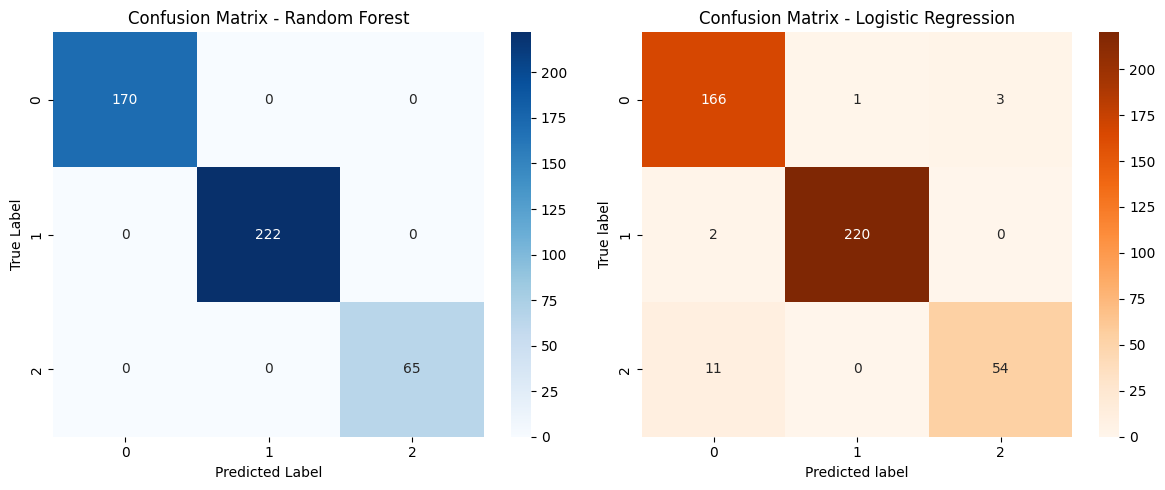

In [10]:
# Hitung Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Confusion Matrix Random Forest
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Random Forest")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot Confusion Matrix Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Oranges", ax=axes[1])
axes[1].set_title("Confusion Matrix - Logistic Regression")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

# Show
plt.tight_layout()
plt.show()

**Analisis Hasil Model**

**1. Random Forest:**
- Accuracy: 100%
- F1-Score: 100%%

- Analisis: Random Forest memiliki performa yang sempurna dibanding Logistic Regression. Model ini dapat mengklasifikasikan cluster secara akurat

- Confusion Matrix: Random Forest memiliki performa yang sangat baik dengan tidak memiliki kesalahan dalam klasifikasi

**2. Logistic Regression:**
- Accuracy: 96.28%
- F1-Score: 96.23%

- Analisis: Logistic Regression memberikan hasil yang baik juga. Model ini lebih sederhana, tetapi tingkat akurasi tidak 100% sempurna

- Confusion Matrix: Logistic Regression masih memiliki beberapa kesalahan, terutama pada cluster 2 (11 salah prediksi berada pada cluster 0) pada cluster 1 (1 salah prediksi berada pada cluster 0), dan cluster 0 (3 salah prediksi berada pada cluster 0)

## **c. Analisis Hasil Evaluasi Model Klasifikasi**

**1. Identifikasi Kelemahan Model**

**- Precision atau Recall rendah untuk kelas tertentu** 
- Dari confusion matrix terlihat model Logistic Regression masih memiliki beberapa kesalahan dalam mengklasifikasikan beberapa cluster.
- Sedangkan, model Random Forest sempurna dalam proses klasifikasi cluster.

**- Apakah model mengalami overfitting atau underfitting?**
- Mungkin tanda overfitting dapat terlihat dari model Random Forest sebab hampir tidak ada kesalahan dalam klasifikasi. Hal ini menyebabkan model kurang ter-generalisasi pada data baru dan terlalu menyesuaikan pada data latih.
- Logistic Regression memiliki beberapa kesalahan tetapi masih terbilang cukup akurat di 96.28%. Model ini mungkin lebih baik untuk generalisasi pada data baru meskipun kurang presisi dibandingkan Random Forest.

**2. Rekomendasi Tindakan Lanjutan**
- Jika ingin mengatasi overfitting pada model Random Forest, dapat mencoba hyperparamter tunning seperti mengatur kedalaman pohon (max depth) dan mengatur nilai (n_estimator) yang mana semakin besar semakin stabil tetapi masih dalam batas wajar.

- Jika hasil belum memuaskan, dapat menggunakan model lainnya seperti Decision Tree, SVM atau lainnya.